<a href="https://colab.research.google.com/github/MatteoBaraldi/Machine-Learning-for-Bioengineering/blob/giovanni/MOD-1/notebooks/06_weight_decay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Weight Decay and Overfitting – Interactive Demo

In this demo, we use polynomial regression with a fixed high degree (degree = 25) to explore the effects of weight decay (L2 regularization).

The true function we want to learn is a simple quadratic curve.
We generate noisy observations of that curve.

You can interactively adjust:
- The strength of the weight decay (`lambda` value)
- The noise level added to the data

Use the sliders to observe how regularization helps control overfitting, improves generalization, and stabilizes the model even when using a high-capacity polynomial model.

In [1]:
# Install ipywidgets if not already available
!pip install ipywidgets --quiet

from ipywidgets import interact
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge #this instead of LinearRegression --> this introduces regularization
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Base data (same for all runs), same datas and set as before in underfitting and overfitting
np.random.seed(0)
n_samples = 100
X = np.linspace(0, 1, n_samples).reshape(-1, 1)
# True underlying function
y_true = 4 * (X.ravel() - 0.5) ** 2

# Fixed high degree for polynomial expansion --> deliberately excessive order will lead to overfit and see how regularization will fix this
fixed_degree = 25

# Interactive plot function
def plot_weight_decay(lambda_value=0.0, noise_std=0.1):
    # Generate noisy labels
    y = y_true + noise_std * np.random.randn(n_samples)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Polynomial features
    poly = PolynomialFeatures(degree=fixed_degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Train model with Ridge regression (weight decay): ridge regression adds a penalty term for the size of the coefficients: it is not simply
    #minimized Σ(y - ŷ)² of ordinary linear regression but: Σ(y - ŷ)² + λ · Σ(weight²) with lambda hyperparameters controlling weights
    model = Ridge(alpha=lambda_value)  # Ridge implements L2 regularization
    model.fit(X_train_poly, y_train)

    # Predictions and errors
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    # Plotting
    X_plot = np.linspace(0, 1, 200).reshape(-1, 1)
    y_plot = model.predict(poly.transform(X_plot))

    plt.figure(figsize=(7, 5)) #in blue noisy training points while in red model's fitted curve in green true parabola
    plt.scatter(X_train, y_train, color='blue', label='Train data', s=20)
    plt.plot(X_plot, y_plot, color='red', label=f'Degree {fixed_degree}')
    plt.plot(X, y_true, '--', color='green', label='True function')
    plt.title(f"Train MSE = {train_mse:.4f} | Test MSE = {test_mse:.4f}\nNoise std = {noise_std} | Lambda = {lambda_value}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()

# Activate interactive widgets for lambda and noise values
interact(plot_weight_decay, lambda_value=(0.0, 0.2, 0.05), noise_std=(0.0, 1.0, 0.05))
#lambda 0 with high noise train error small but high in test error (overfitting); increasing lambda smoother curve and test MSE DROPS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 28.9 MB/s eta 0:00:00


interactive(children=(FloatSlider(value=0.0, description='lambda_value', max=0.2, step=0.05), FloatSlider(valu…

<function __main__.plot_weight_decay(lambda_value=0.0, noise_std=0.1)>

# 📊 MSE vs Weight Decay (Lambda)

This plot shows how the training and test Mean Squared Error (MSE) change as we increase the strength of weight decay (lambda) in a high-degree polynomial model (degree = 25).

We compare two scenarios:
- Low noise (noise_std = 0.15)
- High noise (noise_std = 0.25)

Key insights:
- When lambda = 0 (no weight decay), the model tends to overfit, especially with noisy data.
- Increasing lambda helps reduce overfitting by penalizing large weights, leading to better generalization.
- If lambda becomes too large, the model may underfit and the error increases again.

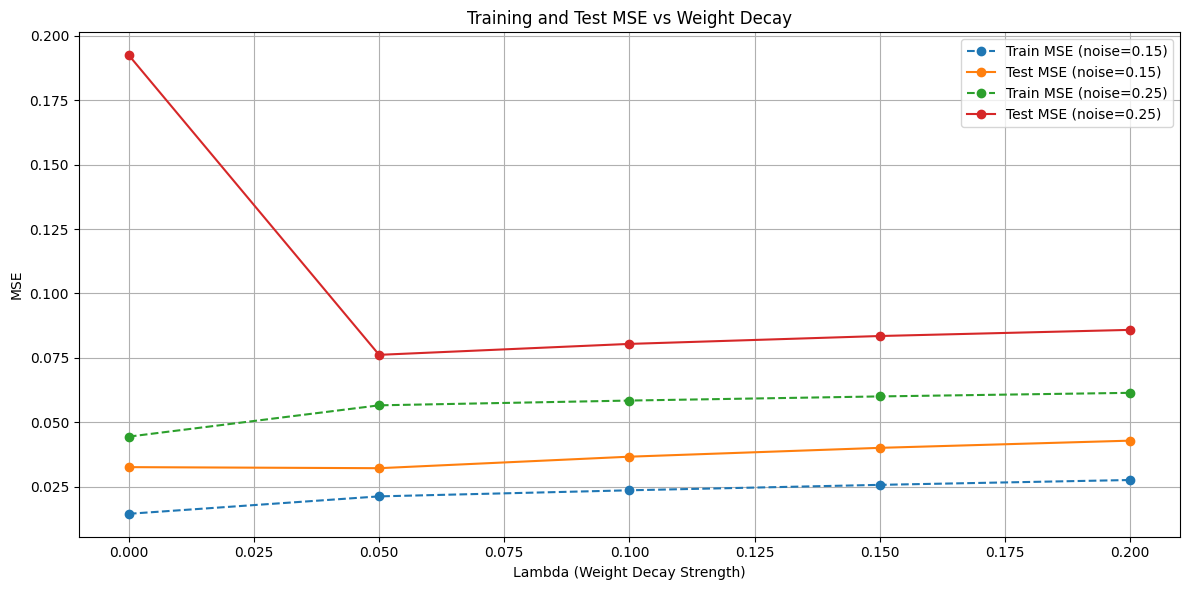

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Base data
np.random.seed(0)
n_samples = 100
X = np.linspace(0, 1, n_samples).reshape(-1, 1)
y_true = 4 * (X.ravel() - 0.5) ** 2

# Settings
fixed_degree = 25
noise_levels = [0.15, 0.25] #FIXING two noise levels, low and moderate; with degree fixed the point is to vary lambda
lambdas = np.arange(0.0, 0.25, 0.05)

plt.figure(figsize=(12, 6))

for noise_std in noise_levels: #outer LOOP over NOISE LEVELS --> FOR FINAL UNBIASED EVALUATION
    y = y_true + noise_std * np.random.randn(n_samples)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    train_mse = []
    test_mse = []

    for lambda_value in lambdas: #INNER LOOP FOR MAKING CHOICES, FOR EXAMPLE ABOUT HYOERPARAMETER
        # Polynomial features
        poly = PolynomialFeatures(fixed_degree)
        X_train_poly = poly.fit_transform(X_train)
        X_test_poly = poly.transform(X_test)

        # Model with Ridge (weight decay)
        model = Ridge(alpha=lambda_value)
        model.fit(X_train_poly, y_train)

        y_train_pred = model.predict(X_train_poly)
        y_test_pred = model.predict(X_test_poly)

        train_mse.append(mean_squared_error(y_train, y_train_pred))
        test_mse.append(mean_squared_error(y_test, y_test_pred))

    # Plot for current noise level
    plt.plot(lambdas, train_mse, linestyle='--', marker='o', label=f'Train MSE (noise={noise_std})')
    plt.plot(lambdas, test_mse, marker='o', label=f'Test MSE (noise={noise_std})')

plt.xlabel('Lambda (Weight Decay Strength)')
plt.ylabel('MSE')
plt.title('Training and Test MSE vs Weight Decay')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#FINAL CONSIDERATIONS: TRAIN MSE starts low for lambda=0 and increases as lambda increases (model is restricted from fitting anything)
#TEST MSE starts high as lambda=0 then decreases with lambda increasing reaching a minimum, than if lamda too large error increase again --> UNDERFITTING
#--> THIS SHOWS HOW IS BETTER TO EVALUATE LAMBDA THROUGH A VALIDATION SET THEN EVALUATE MODEL ON NEW TEST SET, never selecting it directly from test set
#for the high noise case, points are more scattered, model shows wider oscillations to take all points (TEST MSE STARTS HIGHER);
#by increasing lambda regularization aggresively shrinks oversized coefficients giving a large and fast improvement in MSE